## GAN


In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


import matplotlib.pyplot as plt

In [2]:
X = torch.normal(0.0, 1, (1000, 2))
A = torch.tensor([[1, 2], [-0.1, 0.5]])
b = torch.tensor([1, 2])
data = torch.matmul(X, A) + b

The covariance matrix is
tensor([[1.0100, 1.9500],
        [1.9500, 4.2500]])


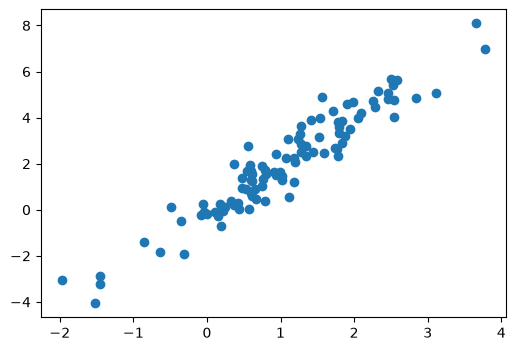

In [3]:
print(f"The covariance matrix is\n{torch.matmul(A.T, A)}")
plt.figure(figsize=(6, 4))
plt.scatter(data[:100, 0].detach().numpy(), data[:100, 1].detach().numpy())

plt.show()

In [4]:
batch_size = 8
dataset = TensorDataset(data)
data_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
net_G = nn.Sequential(nn.Linear(2, 2))

net_D = nn.Sequential(
    nn.Linear(2, 5),
    nn.Tanh(),
    nn.Linear(5, 3),
    nn.Tanh(),
    nn.Linear(3, 1),
)

In [6]:
def update_D(X, Z, net_D, net_G, loss_fn, optimizer):
    batch_size = X.shape[0]
    optimizer.zero_grad()
    real_Y = net_D(X)
    fake_Y = net_D(net_G(Z).detach())
    loss = (
        loss_fn(real_Y, torch.ones(batch_size, device=X.device).reshape(real_Y.shape))
        + loss_fn(
            fake_Y, torch.zeros(batch_size, device=X.device).reshape(fake_Y.shape)
        )
    ) / 2
    loss.backward()
    optimizer.step()
    return loss.item()


def update_G(Z, net_D, net_G, loss_fn, optimizer):
    optimizer.zero_grad()
    fake_X = net_G(Z)
    fake_Y = net_D(fake_X)
    loss = loss_fn(
        fake_Y, torch.ones(Z.shape[0], device=Z.device).reshape(fake_Y.shape)
    )
    loss.backward()
    optimizer.step()
    return loss.item()


def plot_loss(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

In [7]:
optimizer_D = torch.optim.Adam(net_D.parameters())
optimizer_G = torch.optim.Adam(net_G.parameters())
for w in net_D.parameters():
    nn.init.normal_(w, 0, 0.2)
for w in net_G.parameters():
    nn.init.normal_(w, 0, 0.2)

Epoch1----------------------------------------------------------
Generator Loss : 0.6357147374153137
Discriminator Loss : 0.690725067615509
Epoch2----------------------------------------------------------
Generator Loss : 0.7517928538322449
Discriminator Loss : 0.6355963106155396
Epoch3----------------------------------------------------------
Generator Loss : 0.9863402218818664
Discriminator Loss : 0.5726920683383941
Epoch4----------------------------------------------------------
Generator Loss : 1.100707086086273
Discriminator Loss : 0.5608774797916413
Epoch5----------------------------------------------------------
Generator Loss : 1.0844712924957276
Discriminator Loss : 0.587401341676712
Epoch6----------------------------------------------------------
Generator Loss : 0.9977574734687805
Discriminator Loss : 0.6118836171627045
Epoch7----------------------------------------------------------
Generator Loss : 0.951551522731781
Discriminator Loss : 0.6152674157619477
Epoch8-----------

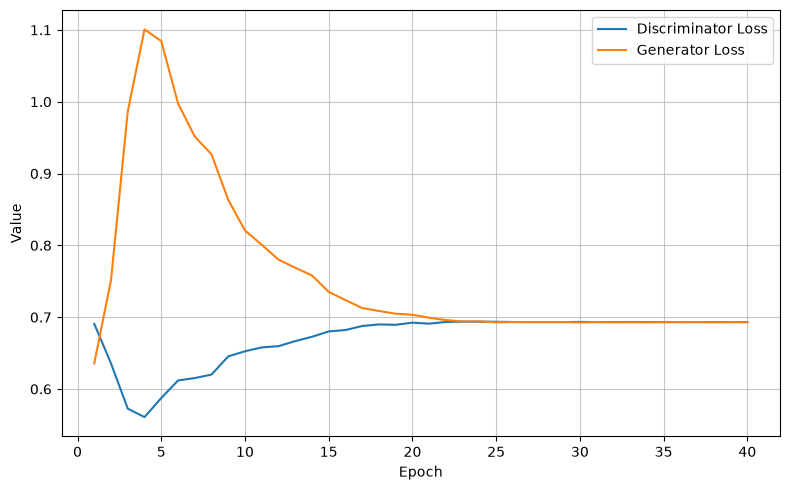

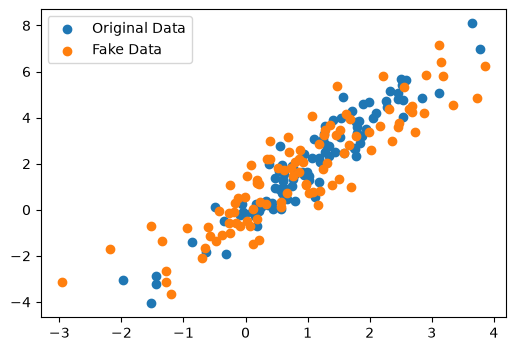

In [8]:
loss_history = {"Discriminator Loss": [], "Generator Loss": []}
LATENT_DIM = 2
LOSS_FN = nn.BCEWithLogitsLoss()
EPOCHS = 40
len_iter = len(data_iter)

for epoch in range(EPOCHS):
    loss_D, loss_G = 0, 0
    print(f"Epoch{epoch+1}----------------------------------------------------------")
    for (X,) in data_iter:

        Z = torch.normal(0, 1, (batch_size, LATENT_DIM))
        loss_D += update_D(X, Z, net_D, net_G, LOSS_FN, optimizer_D)
        loss_G += update_G(Z, net_D, net_G, LOSS_FN, optimizer_G)
    loss_G /= len_iter
    loss_D /= len_iter
    loss_history["Discriminator Loss"].append(loss_D)
    loss_history["Generator Loss"].append(loss_G)
    print(f"Generator Loss : {loss_G}")
    print(f"Discriminator Loss : {loss_D}")

plot_loss(loss_history)

Z = torch.normal(0, 1, size=(100, LATENT_DIM))
fake_X = net_G(Z).detach().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(
    data[:100, 0].detach().numpy(),
    data[:100, 1].detach().numpy(),
    label="Original Data",
)
plt.scatter(fake_X[:, 0], fake_X[:, 1], label="Fake Data")
plt.legend()

plt.show()

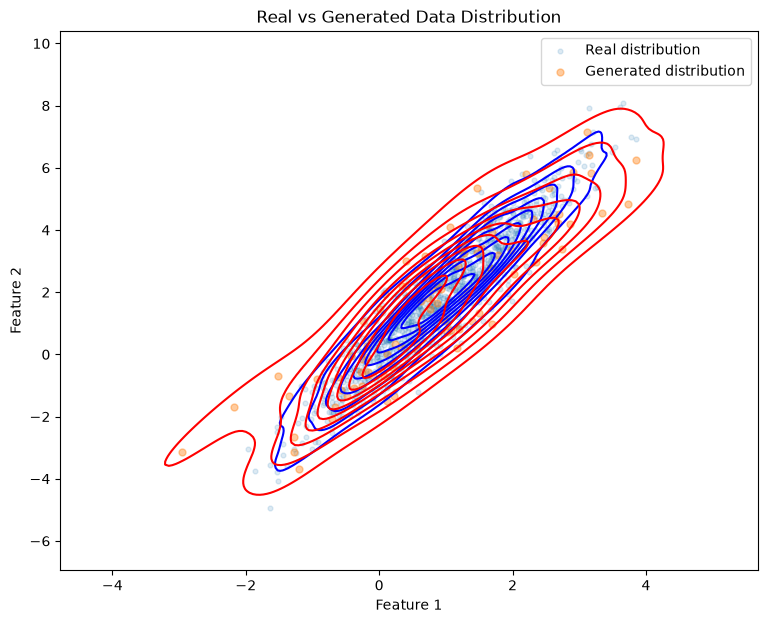

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert torch → numpy
real = data.detach().cpu().numpy()
fake = fake_X

plt.figure(figsize=(9, 7))

# Real distribution
sns.kdeplot(x=real[:, 0], y=real[:, 1], color="blue")

# Fake distribution
sns.kdeplot(x=fake[:, 0], y=fake[:, 1], color="red")

# Points
plt.scatter(real[:, 0], real[:, 1], s=12, alpha=0.15, label="Real distribution")

plt.scatter(fake[:, 0], fake[:, 1], s=25, alpha=0.4, label="Generated distribution")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Real vs Generated Data Distribution")
plt.legend()

plt.show()

In [10]:
def estimate_js_divergence(X, Z, net_D, net_G):

    with torch.no_grad():

        # Real samples
        real_logits = net_D(X)
        real_prob = torch.sigmoid(real_logits)

        # Fake samples
        fake_X = net_G(Z)
        fake_logits = net_D(fake_X)
        fake_prob = torch.sigmoid(fake_logits)

        eps = 1e-8

        js = (
            0.5 * torch.log2(2 * real_prob + eps).mean()
            + 0.5 * torch.log2(2 * (1 - fake_prob) + eps).mean()
        )

    return js.item()

In [11]:
estimate_js_divergence(X, Z, net_D, net_G)

-0.0003090991813223809

## DCGAN


In [12]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision.datasets.folder import default_loader
from torchinfo import summary


import matplotlib.pyplot as plt

from tqdm import tqdm

In [13]:
import os
import zipfile
import requests
from PIL import Image
from torchvision import datasets
from torchvision.transforms import v2

cwd = os.getcwd()
os.chdir("..")

# Actual D2L dataset URL
url = "http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip"

zip_path = os.path.join("data", "pokemon.zip")
extract_dir = "data"

if not os.path.exists("data/pokemon"):

    # -----------------------------
    # 1. Download
    # -----------------------------
    response = requests.get(url)
    response.raise_for_status()

    print("Status:", response.status_code)
    print("Content-Type:", response.headers.get("Content-Type"))
    print("Downloaded:", len(response.content), "bytes")

    # Check that it is actually a ZIP
    if not response.content.startswith(b"PK"):
        print(response.text[:500])
        raise ValueError("Downloaded file is not a ZIP file.")

    with open(zip_path, "wb") as f:
        f.write(response.content)

    print("Saved to:", os.path.abspath(zip_path))

    # -----------------------------
    # 2. Extract
    # -----------------------------
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print("Extracted successfully!")

    # -----------------------------
    # 3. Find the dataset directory
    # -----------------------------
    for root, dirs, files in os.walk(extract_dir):
        print(root)


# -----------------------------
# 4. Load with ImageFolder
# -----------------------------


def load_rgb(path):
    img = Image.open(path).convert("RGBA")

    background = Image.new("RGBA", img.size, "WHITE")
    background.alpha_composite(img)

    return background.convert("RGB")


pokemon_path = r"C:\Users\USER\ipnyb files\data\pokemon"
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.RGB(),
        v2.Resize((64, 64)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ]
)
pokemon = datasets.ImageFolder(
    root=pokemon_path,
    loader=load_rgb,
    transform=transform,
)

print("Number of images:", len(pokemon))
print("Number of classes:", len(pokemon.classes))
print("Classes:", pokemon.classes[:10])
print("Class indices:", list(pokemon.class_to_idx.items())[:10])


# Restore original directory
os.chdir(cwd)

Number of images: 40597
Number of classes: 721
Classes: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
Class indices: [('1', 0), ('10', 1), ('100', 2), ('101', 3), ('102', 4), ('103', 5), ('104', 6), ('105', 7), ('106', 8), ('107', 9)]


In [14]:
batch_size = 256
dataloader = DataLoader(
    pokemon,
    batch_size=batch_size,
    shuffle=True,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].


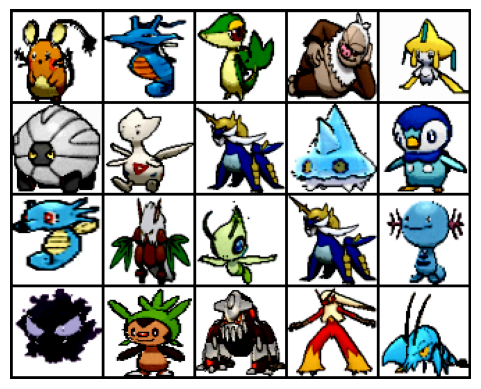

In [15]:
for X, y in dataloader:
    imgs = make_grid(X[:20], 5)
    break

plt.imshow(imgs.permute(1, 2, 0))
plt.axis(False)
plt.show()

### Transposed Convolution Output Size

- Output height: $$H_{\text{out}} = (H_{\text{in}} - 1)s_h - 2p_h + k_h$$
- Output width: $$W_{\text{out}} = (W_{\text{in}} - 1)s_w - 2p_w + k_w$$
- Therefore:$$H_{\text{out}} \times W_{\text{out}}=\left[(H_{\text{in}} - 1)s_h - 2p_h + k_h\right]\times\left[(W_{\text{in}} - 1)s_w - 2p_w + k_w\right]$$
- Where: <br>
  $
k_h, k_w = \text{kernel height and width}
$
  <br>
  $
s_h, s_w = \text{stride along height and width}
$
  <br>
  $
p_h, p_w = \text{padding along height and width}
$


In [16]:
from typing import Any


class G_block(nn.Module):
    def __init__(
        self,
        out_channels,
        in_channels=3,
        kernel_size=4,
        stride=2,
        padding=1,
        *args: Any,
        **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.conv2d_tran_seq = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.conv2d_tran_seq(x)


summary(G_block(20), input_size=(2, 3, 16, 16))

Layer (type:depth-idx)                   Output Shape              Param #
G_block                                  [2, 20, 32, 32]           --
├─Sequential: 1-1                        [2, 20, 32, 32]           --
│    └─ConvTranspose2d: 2-1              [2, 20, 32, 32]           960
│    └─BatchNorm2d: 2-2                  [2, 20, 32, 32]           40
│    └─ReLU: 2-3                         [2, 20, 32, 32]           --
Total params: 1,000
Trainable params: 1,000
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.97
Input size (MB): 0.01
Forward/backward pass size (MB): 0.66
Params size (MB): 0.00
Estimated Total Size (MB): 0.67

In [17]:
n_G = 64
net_G = nn.Sequential(
    G_block(in_channels=100, out_channels=n_G * 8, kernel_size=2, stride=1, padding=0),
    # Output: (64 * 8, 2, 2)
    G_block(in_channels=n_G * 8, out_channels=n_G * 4),  # Output: (64 * 4, 4, 4)
    G_block(in_channels=n_G * 4, out_channels=n_G * 2),  # Output: (64 * 2, 8, 8)
    G_block(in_channels=n_G * 2, out_channels=n_G),  # Output: (64, 16, 16)
    G_block(in_channels=n_G, out_channels=32),  # Output: (32, 32, 32)
    nn.ConvTranspose2d(
        in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1, bias=False
    ),
    nn.Tanh(),
)  # Output: (3, 64, 64)

summary(net_G, (1, 100, 1, 1))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 3, 64, 64]            --
├─G_block: 1-1                           [1, 512, 2, 2]            --
│    └─Sequential: 2-1                   [1, 512, 2, 2]            --
│    │    └─ConvTranspose2d: 3-1         [1, 512, 2, 2]            204,800
│    │    └─BatchNorm2d: 3-2             [1, 512, 2, 2]            1,024
│    │    └─ReLU: 3-3                    [1, 512, 2, 2]            --
├─G_block: 1-2                           [1, 256, 4, 4]            --
│    └─Sequential: 2-2                   [1, 256, 4, 4]            --
│    │    └─ConvTranspose2d: 3-4         [1, 256, 4, 4]            2,097,152
│    │    └─BatchNorm2d: 3-5             [1, 256, 4, 4]            512
│    │    └─ReLU: 3-6                    [1, 256, 4, 4]            --
├─G_block: 1-3                           [1, 128, 8, 8]            --
│    └─Sequential: 2-3                   [1, 128, 8, 8]            --

In [18]:
from typing import Any


class D_block(nn.Module):
    def __init__(
        self,
        out_channels,
        in_channels=3,
        kernel_size=4,
        stride=2,
        padding=1,
        alpha=0.2,
        *args: Any,
        **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.conv2d_tran_seq = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(alpha),
        )

    def forward(self, x):
        return self.conv2d_tran_seq(x)


summary(D_block(20), input_size=(2, 3, 16, 16))

Layer (type:depth-idx)                   Output Shape              Param #
D_block                                  [2, 20, 8, 8]             --
├─Sequential: 1-1                        [2, 20, 8, 8]             --
│    └─Conv2d: 2-1                       [2, 20, 8, 8]             960
│    └─BatchNorm2d: 2-2                  [2, 20, 8, 8]             40
│    └─LeakyReLU: 2-3                    [2, 20, 8, 8]             --
Total params: 1,000
Trainable params: 1,000
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.12
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [19]:
n_D = 64
net_D = nn.Sequential(
    D_block(n_D),  # Output: (64, 32, 32)
    D_block(in_channels=n_D, out_channels=n_D * 2),  # Output: (64 * 2, 16, 16)
    D_block(in_channels=n_D * 2, out_channels=n_D * 4),  # Output: (64 * 4, 8, 8)
    D_block(in_channels=n_D * 4, out_channels=n_D * 8),  # Output: (64 * 8, 4, 4)
    nn.Conv2d(in_channels=n_D * 8, out_channels=1, kernel_size=4, bias=False),
)  # Output: (1, 1, 1)

summary(net_D, (1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1, 1, 1]              --
├─D_block: 1-1                           [1, 64, 32, 32]           --
│    └─Sequential: 2-1                   [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           3,072
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           128
│    │    └─LeakyReLU: 3-3               [1, 64, 32, 32]           --
├─D_block: 1-2                           [1, 128, 16, 16]          --
│    └─Sequential: 2-2                   [1, 128, 16, 16]          --
│    │    └─Conv2d: 3-4                  [1, 128, 16, 16]          131,072
│    │    └─BatchNorm2d: 3-5             [1, 128, 16, 16]          256
│    │    └─LeakyReLU: 3-6               [1, 128, 16, 16]          --
├─D_block: 1-3                           [1, 256, 8, 8]            --
│    └─Sequential: 2-3                   [1, 256, 8, 8]            --
│    

In [20]:
def update_D(X, Z, net_D, net_G, loss_fn, optimizer, device):
    net_D = net_D.to(device)
    net_G = net_G.to(device)
    X, Z = X.to(device), Z.to(device)
    optimizer.zero_grad()
    real_Y = net_D(X)
    fake_Y = net_D(net_G(Z).detach())
    loss = (
        loss_fn(real_Y, torch.full_like(real_Y, 0.9))
        + loss_fn(fake_Y, torch.full_like(fake_Y, 0.1))
    ) / 2
    loss.backward()
    optimizer.step()
    return loss.item()


def update_G(Z, net_D, net_G, loss_fn, optimizer, device):
    net_D = net_D.to(device)
    net_G = net_G.to(device)
    Z = Z.to(device)
    optimizer.zero_grad()
    fake_X = net_G(Z)
    fake_Y = net_D(fake_X)
    loss = loss_fn(fake_Y, torch.ones_like(fake_Y))
    loss.backward()
    optimizer.step()
    return loss.item()


def plot_loss(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

In [21]:
optimizer_D = torch.optim.Adam(net_D.parameters())
optimizer_G = torch.optim.Adam(net_G.parameters())
for w in net_D.parameters():
    nn.init.normal_(w, 0, 0.2)
for w in net_G.parameters():
    nn.init.normal_(w, 0, 0.2)

Epoch1----------------------------------------------------------


Epoch 1/10: 100%|██████████| 159/159 [01:04<00:00,  2.47it/s]


Generator Loss : 7.6864862621955155
Discriminator Loss : 0.4755050620567874
Epoch2----------------------------------------------------------


Epoch 2/10: 100%|██████████| 159/159 [00:46<00:00,  3.41it/s]


Generator Loss : 3.6932360916017735
Discriminator Loss : 0.38291713351723533
Epoch3----------------------------------------------------------


...

Generator Loss : 2.5595498534868346
Discriminator Loss : 0.3436509843142527
Epoch9----------------------------------------------------------


Epoch 9/10: 100%|██████████| 159/159 [00:52<00:00,  3.02it/s]


Generator Loss : 2.6112202773304105
Discriminator Loss : 0.34743248535402166
Epoch10----------------------------------------------------------


Epoch 10/10: 100%|██████████| 159/159 [00:50<00:00,  3.18it/s]

Generator Loss : 2.5821007767563344
Discriminator Loss : 0.35044819885079964


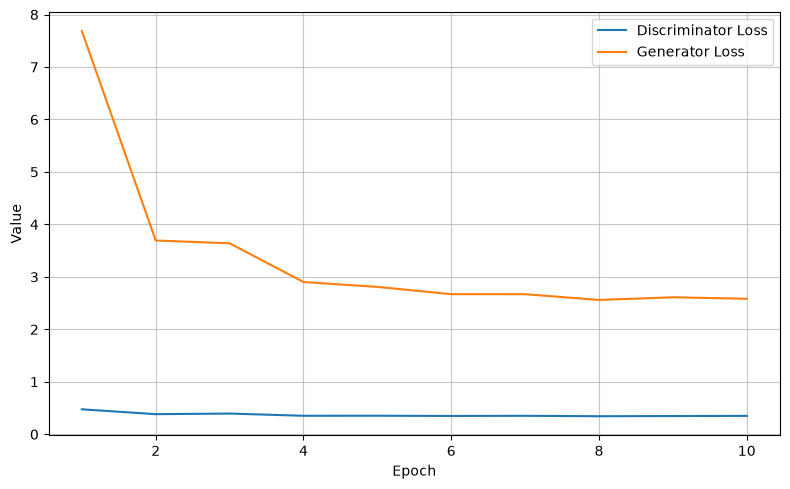

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99810904..0.99996984].


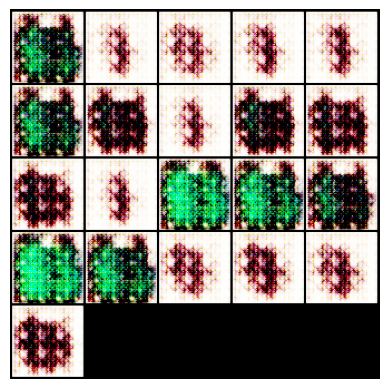

In [22]:
loss_history = {"Discriminator Loss": [], "Generator Loss": []}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LATENT_DIM = 100
LOSS_FN = nn.BCEWithLogitsLoss()
EPOCHS = 10
len_iter = len(dataloader)

for epoch in range(EPOCHS):
    loss_D, loss_G = 0, 0
    print(f"Epoch{epoch+1}----------------------------------------------------------")
    for X, _ in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):

        Z = torch.normal(0, 1, (batch_size, LATENT_DIM, 1, 1))
        loss_D += update_D(X, Z, net_D, net_G, LOSS_FN, optimizer_D, DEVICE)
        loss_G += update_G(Z, net_D, net_G, LOSS_FN, optimizer_G, DEVICE)
    loss_G /= len_iter
    loss_D /= len_iter
    loss_history["Discriminator Loss"].append(loss_D)
    loss_history["Generator Loss"].append(loss_G)
    print(f"Generator Loss : {loss_G}")
    print(f"Discriminator Loss : {loss_D}")

plot_loss(loss_history)

Z = torch.normal(0, 1, size=(21, LATENT_DIM, 1, 1), device=DEVICE)
fake_X = net_G(Z).detach().cpu()
gen_imgs = make_grid(fake_X, 5)

plt.imshow(gen_imgs.permute(1, 2, 0))
plt.axis(False)
plt.show()

## WGAN


In [23]:
from torch.utils.data import TensorDataset

X = torch.normal(0.0, 1, (1000, 2))
A = torch.tensor([[1, 2], [-0.1, 0.5]])
b = torch.tensor([1, 2])
data = torch.matmul(X, A) + b

batch_size = 8
dataset = TensorDataset(data)
data_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [24]:
net_G = nn.Sequential(nn.Linear(2, 2))

net_C = nn.Sequential(
    nn.Linear(2, 5),
    nn.Tanh(),
    nn.Linear(5, 3),
    nn.Tanh(),
    nn.Linear(3, 1),
)

In [25]:
def update_C_wasserstein(X, Z, net_C, net_G, optimizer, device):
    net_C = net_C.to(device)
    net_G = net_G.to(device)
    X, Z = X.to(device), Z.to(device)
    optimizer.zero_grad()
    real_Y = net_C(X)
    fake_Y = net_C(net_G(Z).detach())
    loss = -real_Y.mean() + fake_Y.mean()
    loss.backward()
    optimizer.step()
    for p in net_C.parameters():
        p.data.clamp_(-0.01, 0.01)
    return loss.item()


def update_G_wasserstein(Z, net_C, net_G, optimizer, device):
    net_C = net_C.to(device)
    net_G = net_G.to(device)
    Z = Z.to(device)
    optimizer.zero_grad()
    fake_X = net_G(Z)
    fake_Y = net_C(fake_X)
    loss = -fake_Y.mean()
    loss.backward()
    optimizer.step()
    return loss.item()

In [26]:
optimizer_C = torch.optim.Adam(net_C.parameters())
optimizer_G = torch.optim.Adam(net_G.parameters())
for w in net_C.parameters():
    nn.init.normal_(w, 0, 0.2)
for w in net_G.parameters():
    nn.init.normal_(w, 0, 0.2)

Epoch1------------------------------------------------------------
Critic Loss : -3.986635953187944e-05
Generator Loss : -0.0099360873401165
Epoch2------------------------------------------------------------
Critic Loss : -3.326547890901567e-05
Generator Loss : -0.009945008881390095
Epoch3------------------------------------------------------------
Critic Loss : -2.941196560859681e-05
Generator Loss : -0.009950360916554928
Epoch4------------------------------------------------------------
Critic Loss : -2.5482919812202456e-05
Generator Loss : -0.009954788826406002
Epoch5------------------------------------------------------------
Critic Loss : -2.1765759587287904e-05
Generator Loss : -0.009957912556827068
Epoch6------------------------------------------------------------
Critic Loss : -1.8200002610683444e-05
Generator Loss : -0.009957626782357693
Epoch7------------------------------------------------------------
Critic Loss : -1.6350226104259492e-05
Generator Loss : -0.0099621953368186

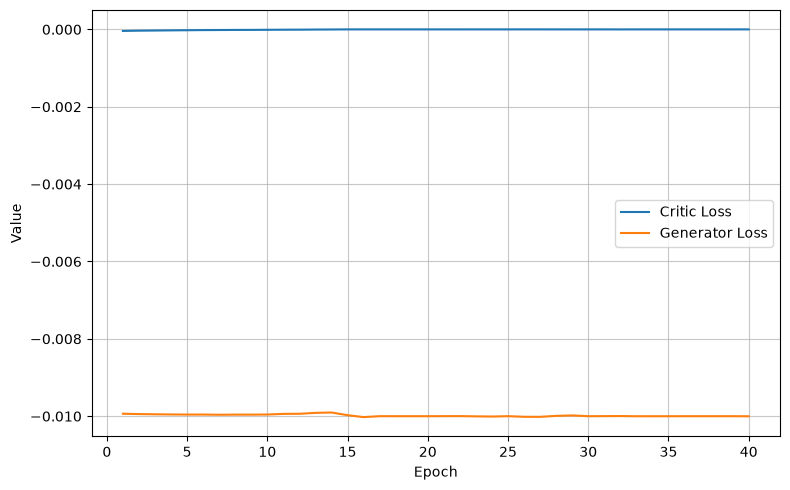

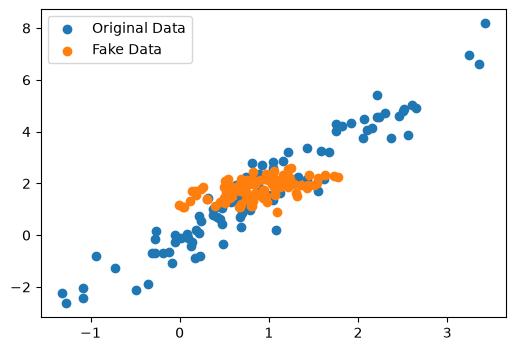

In [27]:
loss_history = {"Critic Loss": [], "Generator Loss": []}
CRITIC_STEPS = 5
EPOCHS = 40
LATENT_DIM = 2
len_iter = len(data_iter)

for epoch in range(EPOCHS):
    print(f"Epoch{epoch+1}------------------------------------------------------------")
    loss_C, loss_G = 0, 0
    for (X,) in data_iter:

        # Train critic 5 times
        batch_loss_C = 0
        for _ in range(CRITIC_STEPS):
            Z = torch.normal(0, 1, (X.shape[0], LATENT_DIM))
            batch_loss_C += update_C_wasserstein(X, Z, net_C, net_G, optimizer_C, DEVICE)
        batch_loss_C /= CRITIC_STEPS
        loss_C += batch_loss_C
        # Train generator once
        Z = torch.normal(0, 1, (X.shape[0], LATENT_DIM))

        loss_G += update_G_wasserstein(Z, net_C, net_G, optimizer_G, DEVICE)
    loss_C /= len_iter
    loss_G /= len_iter
    loss_history["Critic Loss"].append(loss_C)
    loss_history["Generator Loss"].append(loss_G)
    print(f"Critic Loss : {loss_C}")
    print(f"Generator Loss : {loss_G}")

plot_loss(loss_history)

Z = torch.normal(0, 1, size=(100, LATENT_DIM), device=DEVICE)
fake_X = net_G(Z).cpu().detach().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(
    data[:100, 0].detach().numpy(),
    data[:100, 1].detach().numpy(),
    label="Original Data",
)
plt.scatter(fake_X[:, 0], fake_X[:, 1], label="Fake Data")
plt.legend()

plt.show()

# Review

In [28]:
import torch
from torch import nn

In [ ]:
gen_net = nn.Sequential(nn.Linear(2,2))

disc_net = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

In [ ]:
def update_G(Z, net_D, net_G, optimizer, loss_fn):
    optimizer.zero_grad()
    fake_X = net_G(Z)
    fake_Y = net_D(fake_X)
    loss = loss_fn(fake_Y, torch.zeros_like(fake_Y))
    loss.backward()
    optimizer.step()
    return loss.item()

def update_D(X, Z, net_D, net_G, optimizer, loss_fn):
    optimizer.zero_grad()
    real_Y = net_D(X)
    fake_Y = net_D(net_G(Z).detach())
    loss = loss_fn(real_Y, torch.ones_like(real_Y))

In [31]:
# Create a simple encoder neural network that converts 784 input features into a 20-dimensional latent representation

In [32]:
from typing import Any


class Encoder(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.seq_encoder = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.LazyLinear(200),
            nn.ReLU(),
            nn.LazyLinear(100),
            nn.ReLU(),
            nn.LazyLinear(50),
            nn.ReLU(),
            nn.LazyLinear(20),
            nn.ReLU()
        )
    def forward(self, x):
        return self.seq_encoder(x)

In [33]:
from torchinfo import summary

summary(Encoder(), (1,784))

Layer (type:depth-idx)                   Output Shape              Param #
Encoder                                  [1, 20]                   --
├─Sequential: 1-1                        [1, 20]                   --
│    └─Linear: 2-1                       [1, 392]                  307,720
│    └─ReLU: 2-2                         [1, 392]                  --
│    └─Linear: 2-3                       [1, 200]                  78,600
│    └─ReLU: 2-4                         [1, 200]                  --
│    └─Linear: 2-5                       [1, 100]                  20,100
│    └─ReLU: 2-6                         [1, 100]                  --
│    └─Linear: 2-7                       [1, 50]                   5,050
│    └─ReLU: 2-8                         [1, 50]                   --
│    └─Linear: 2-9                       [1, 20]                   1,020
│    └─ReLU: 2-10                        [1, 20]                   --
Total params: 412,490
Trainable params: 412,490
Non-trainable para

In [42]:
from typing import Any


class Decoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.seq_decoder = nn.Sequential(
                    nn.Linear(20, 50),
                    nn.ReLU(),
                    nn.LazyLinear(100),
                    nn.ReLU(),
                    nn.LazyLinear(200),
                    nn.ReLU(),
                    nn.LazyLinear(392),
                    nn.ReLU(),
                    nn.LazyLinear(784),
                )

    def forward(self, x):
            return self.seq_decoder(x)

In [40]:
noise = torch.randn((1,20))
noise

tensor([[-0.3647, -2.4653,  0.3063,  0.5211, -1.0569,  0.6608, -0.6773, -0.8997,
         -0.3248, -0.3530,  0.5285,  0.6651,  0.6750,  0.2581,  0.1955,  0.8388,
         -0.5758, -1.5710, -1.1977,  1.7014]])

In [43]:
summary(Decoder(), (1, 20))

Layer (type:depth-idx)                   Output Shape              Param #
Decoder                                  [1, 784]                  --
├─Sequential: 1-1                        [1, 784]                  --
│    └─Linear: 2-1                       [1, 50]                   1,050
│    └─ReLU: 2-2                         [1, 50]                   --
│    └─Linear: 2-3                       [1, 100]                  5,100
│    └─ReLU: 2-4                         [1, 100]                  --
│    └─Linear: 2-5                       [1, 200]                  20,200
│    └─ReLU: 2-6                         [1, 200]                  --
│    └─Linear: 2-7                       [1, 392]                  78,792
│    └─ReLU: 2-8                         [1, 392]                  --
│    └─Linear: 2-9                       [1, 784]                  308,112
Total params: 413,254
Trainable params: 413,254
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Fo